# Titanic Data Analysis
## Explorative Data Analysis Detailed

* *Goal:* refine the exploratory data analysis

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic_Train.csv')

print('Data Load')

Data Load


In [125]:
# First insepction of the data set
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [127]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [128]:
# Checking for missing values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Note:** There are 177 missing values in the age column, 2 missing values in the Embarked column and almost all Cabin values are missing. To fill the missing age values, at first I will extract the title and will replace some specific title into rare. Afterwards I can group the dataset by title and fill the missing values with the median of each group, which is more accurate then filling all the missing values with the mean.

In [129]:
# Extract the title from the name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Checking if it works
print(df['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']


In [130]:
# Replacing 'Mme' 'Ms' 'Lady' and 'Mlle' into Mrs/Miss
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Lady', 'Mrs')

# Check the values again
print(df['Title'].value_counts())

Title
Mr          517
Miss        185
Mrs         127
Master       40
Dr            7
Rev           6
Major         2
Col           2
Don           1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [131]:
# Replacing the rare title into unknown by first creating a list with all the rare titles
unknown_title = ['Dr', 'Rev', 'Major', 'Col', 'Don', 'Sir', 'Capt', 'Countess', 'Jonkheer']

# Replacing into unknown
df['Title'] = df['Title'].replace(unknown_title, 'unknown')

# Check if it works
print(df['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'unknown']


**Note:** Now I have 5 titles which I can group and calculate the median of each group. This way is much better for analysis, because the mean of all is 28 and this will distorts the data.

In [132]:
# Group the dataset by title and fill each group with the median of the group
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))

# Checking the the mean of each group
print(df.groupby('Title')['Age'].mean())

Title
Master      4.466750
Miss       21.681081
Mr         31.823017
Mrs        35.779528
unknown    45.590909
Name: Age, dtype: float64


In [133]:
# Checking the missing values again
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [134]:
# Checking for the most frequent port with 'mode'
# mode is the most frequent value in that column
most_freq_port = df['Embarked'].mode()[0]

# Checking for the output of the most frequent port
print(most_freq_port)

S


In [135]:
# Filling the two missing 'Embarked' values with the most_freq_port
df['Embarked'] = df['Embarked'].fillna(most_freq_port)

# Check for missing values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
dtype: int64

In [136]:
# Extracting the first letter of the Deck 
df['Deck'] = df['Cabin'].str[0]

# Replacing the missing values in 'Deck' with U for unknown
df['Deck'] = df['Deck'].fillna('U')

# Check if it works
print(df['Deck'].unique())

['U' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


In [137]:
# Adding new boolean column 'isChild' for Passenger <18
df['isChild'] = df['Age'] < 18

# Check the column
print(df['isChild'].value_counts())

isChild
False    774
True     117
Name: count, dtype: int64


In [138]:
# Adding new column 'FamiliySize' by add 'SibSp' + 'Parch' + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] +1

# Check the values in the column
print(df['FamilySize'].value_counts())

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


**Note:** With the column FamilySize it is possible to check whether a passenger travels alone or at least with one additional family member.

## Visualization after checking and cleaning the data set

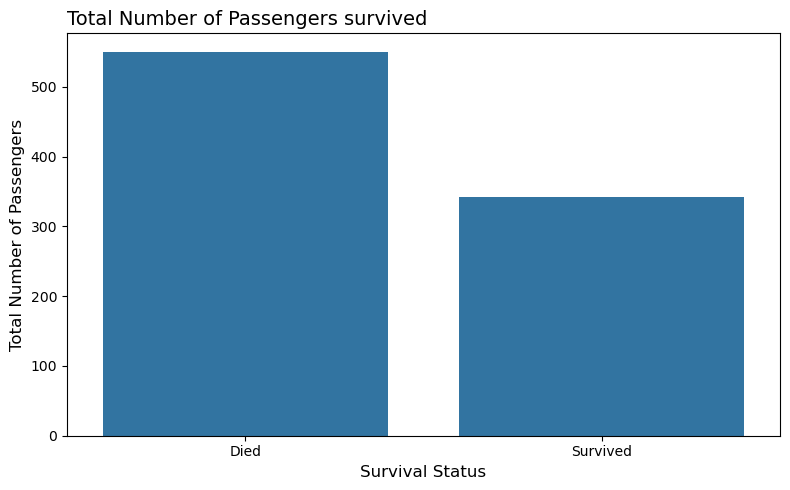

In [139]:
# Visualize the number of passenger survived
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Survived')
plt.title('Total Number of Passengers survived', fontsize=14, loc='left')
plt.xlabel('Survival Status', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Died', 'Survived'])
plt.ylabel('Total Number of Passengers', fontsize=12)

plt.tight_layout()
plt.show()

**Analysis:** The initial chart provides a baseline overview of the survival distribution within the dataset. It reveals a clear unbalance - the number of passengers who perished is significant higher than the number of passengers who survived. This overall baseline highlights that survival was the exception rather than the rule, which sets the context for analyzing which specific factors (such as gender, class, age) increased a passenger's chance of survival

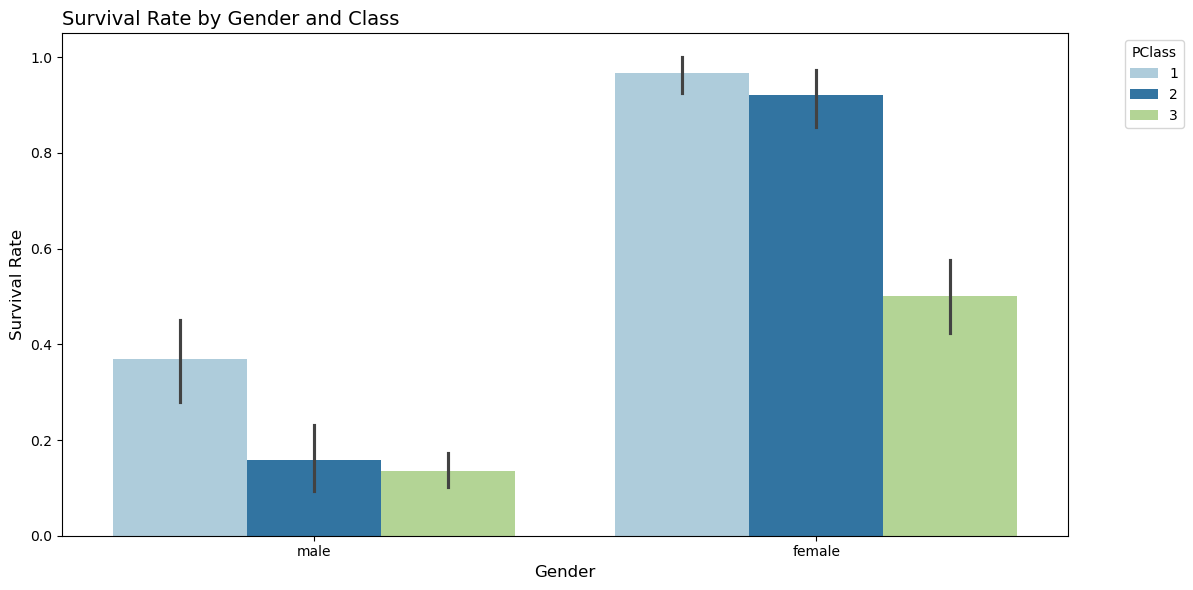

In [140]:
# Visualize the survival rate by gender and class in a bar plot 
plt.figure(figsize=(12,6))

sns.barplot(data=df, x='Sex', y='Survived', hue='Pclass', palette='Paired')
plt.title('Survival Rate by Gender and Class', fontsize=14, loc='left')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='PClass')

plt.tight_layout()
plt.show()

**Analysis:** The Chart reveals, that women travelling the first and second class had the highest survival rate,  with more than 80% in both classes. This indicates that for safety reasons women had a higher priorty to embark on the lifeboats. In contrast, men did not reach 40% in the first class and dropped below 20% in the second and third class. The chart reveals also that the protocol "women and childs first" was strictly followed for passengers travelling in first and second class, whereas passengers travelling in the third class did not have a high survival chance, likley due to their low socioeconomic status.

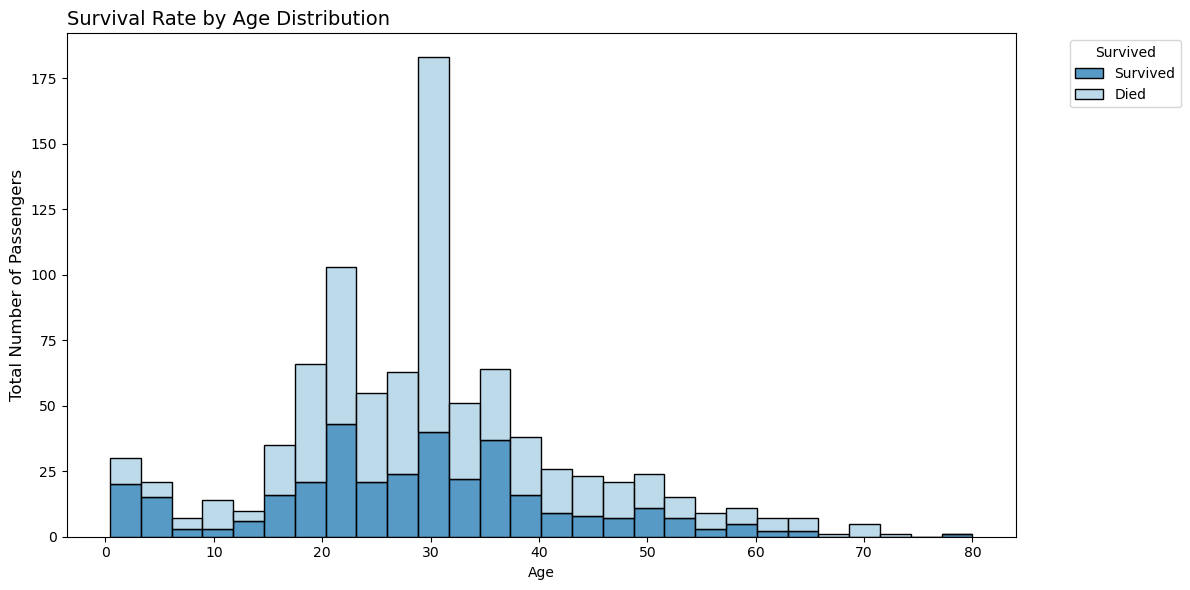

In [141]:
# Question: Does age have an impact on the survival rate?
# Visualize survival rate by age distribution

plt.figure(figsize=(12,6))

sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='Paired')
plt.title('Survival Rate by Age Distribution', fontsize=14, loc='left')
plt.ylabel('Total Number of Passengers', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Survived', labels=['Survived', 'Died'])

plt.tight_layout()
plt.show()


**Analysis:** The histogram reveals that the majority of passengers were young adults between 20 and years old. Whihin this age group, specifically around 20 and 30, the non-survival count was significant higher than the survival count, which reflects the high number of young passengers travelling. For children under the age of 10, there is a relativley high proportion of survivors, especially among toddlers. However, their survival rate is not 100%, indicating that while 'woman and children first' protocol was generally active, factors like passenger class still limited their rescure Above the age of 40, the total number of passengers decrease noticably, and the ratio between survival rate and non-survival rate becomse more balanced.

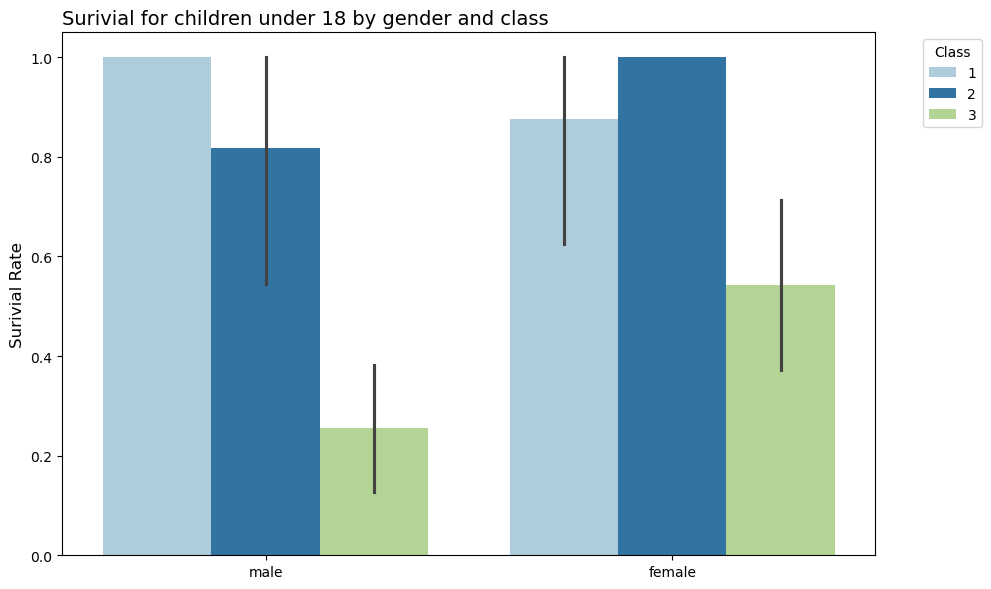

In [143]:
# Question: How high was the survival rate by children by gender and class
# Creating a new df in child_df with all passengers under 18 years
child_df = df[df['Age'] < 18]

plt.figure(figsize=(10,6))
sns.barplot(data=child_df, x='Sex', y='Survived', hue='Pclass', palette='Paired')
plt.title('Surivial for children under 18 by gender and class', fontsize=14, loc='left')
plt.xlabel('')
plt.ylabel('Surivial Rate', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')

plt.tight_layout()
plt.show()


**Analysis:** The Chart reveals that the protocol 'woman and children' first was mostly followed for children in the first and second class. Almost every male children in the first class and all female children in the second class survived. In contrast, male children in the third class had a significant lower surivial rate of around 20%. This indicates that male children passenger had a lower priority for rescue into the lifeboats then female children passenger or faced harder conditions escaping from the lower decks.